In [21]:
import numpy as np

In [22]:
m = 1.0
M = 5.0
L = 2.0
g = -9.81
delta = 1.0

A = np.array(
    [
        [0, 1, 0, 0],
        [0, -delta / M, m * g / M, 0],
        [0, 0, 0, 1],
        [0, -delta / (M * L), -(m + M) * g / (M * L), 0],
    ]
).reshape(4, 4)

B = np.array(
    [
        [0],
        [1 / M],
        [0],
        [1 / (M * L)],
    ]
).reshape(4, 1)


In [23]:
def calculate_observability_matrix(A, C):
    O = np.vstack((C, C @ A, C @ A @ A, C @ A @ A @ A))
    return O

def is_observable(A, C):
    O = calculate_observability_matrix(A, C)
    return np.linalg.matrix_rank(O) == A.shape[0]

print(is_observable(A, np.array([1, 0, 0, 0]))) # True
print(is_observable(A, np.array([0, 1, 0, 0]))) # False
print(is_observable(A, np.array([0, 0, 1, 0]))) # False
print(is_observable(A, np.array([0, 0, 0, 1]))) # False

print(calculate_observability_matrix(A, np.array([0, 1, 0, 0])))
# [[  0.         1.         0.         0.      ]
#  [  0.        -0.2       -1.962      0.      ]
#  [  0.         0.04       0.3924    -1.962   ]
#  [  0.         0.1882   -11.626812   0.3924  ]]

True
False
False
False
[[  0.         1.         0.         0.      ]
 [  0.        -0.2       -1.962      0.      ]
 [  0.         0.04       0.3924    -1.962   ]
 [  0.         0.1882   -11.626812   0.3924  ]]


In [24]:
A_tilde = A[1:, 1:]
B_tilde = B[1:, 0:]
print(is_observable(A_tilde, np.array([[1, 0, 0]]))) # True
print(is_observable(A_tilde, np.array([[0, 1, 0]]))) # True
print(is_observable(A_tilde, np.array([[0, 0, 1]]))) # True

True
True
True


In [25]:
O1 = calculate_observability_matrix(A_tilde, np.array([[1, 0, 0]]))
O2 = calculate_observability_matrix(A_tilde, np.array([[0, 1, 0]]))
O3 = calculate_observability_matrix(A_tilde, np.array([[0, 0, 1]]))

print(np.linalg.det(O1.T @ O1)) # 556.78
print(np.linalg.det(O2.T @ O2)) # 0.37
print(np.linalg.det(O3.T @ O3)) # 0.70

556.7386229104125
0.3757122356000034
0.7086787734155233


In [26]:
A_hang = np.array(
    [
        [0, 1, 0, 0],
        [0, -delta / M, -m * g / M, 0],
        [0, 0, 0, 1],
        [0, delta / (M * L), (m + M) * g / (M * L), 0],
    ]
)
B_hang = np.array([[0], [1 / M], [0], [-1 / (M * L)]])
C_hang = np.array([[1, 0, 0, 0]])

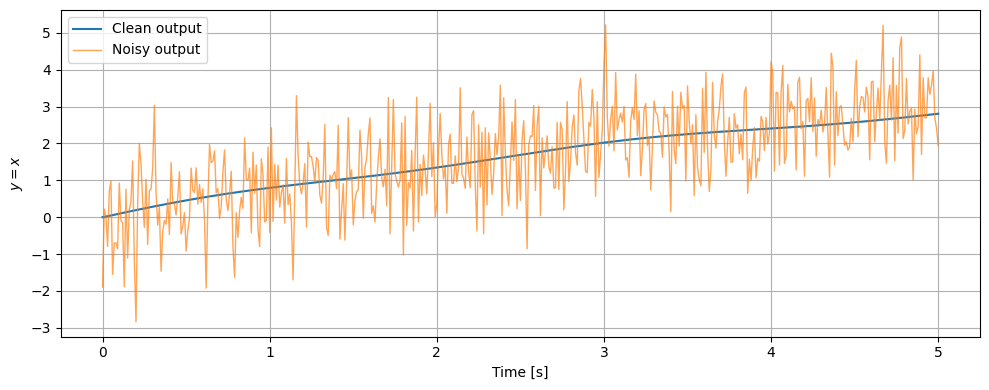

In [27]:
from scipy import signal
import matplotlib.pyplot as plt

# Augmented system 구성
Vd = np.eye(4) * 0.5  # process noise covariance
Vn = np.array([[1.0]])  # measurement noise covariance
B_aug = np.hstack([B_hang, Vd, np.zeros((4, 1))])  # (4, 6)
D_aug = np.hstack([np.zeros((1, 1)), np.zeros((1, 4)), Vn])  # (1, 6)

sys_aug = signal.StateSpace(A_hang, B_aug, C_hang, D_aug)

T = 5.0
dt = 0.01
t = np.arange(0, T + dt, dt)
N = len(t)

# 노이즈 없는 입력: u = impulse, d = 0, n = 0
U_clean = np.zeros((N, 6))
U_clean[0, 0] = 10.0 / dt  # impulse

_, y_clean, x_clean = signal.lsim(sys_aug, U=U_clean, T=t)

# 노이즈 있는 입력: u = impulse, d = process noise, n = measurement noise
np.random.seed(42)
D_noise = np.random.multivariate_normal(np.zeros(4), Vd, N)  # (N, 4)
N_noise = np.random.multivariate_normal(np.zeros(1), Vn, N)  # (N, 1)

U_noisy = np.zeros((N, 6))
U_noisy[0, 0] = 10.0 / dt  # impulse
U_noisy[:, 1:5] = D_noise  # process noise
U_noisy[:, 5:] = N_noise  # measurement noise

_, y_noisy, x_noisy = signal.lsim(sys_aug, U=U_noisy, T=t)

# 비교 플롯
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, y_clean, label="Clean output", linewidth=1.5)
ax.plot(t, y_noisy, label="Noisy output", linewidth=1.0, alpha=0.7)
ax.set_xlabel("Time [s]")
ax.set_ylabel(r"$y = x$")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [28]:
import scipy.linalg

Q_kf = Vd   # process noise covariance
R_kf = Vn   # measurement noise covariance

P = scipy.linalg.solve_continuous_are(A_hang.T, C_hang.T, Q_kf, R_kf)
L = P @ C_hang.T @ np.linalg.inv(R_kf)
print(L)
#[[ 1.48600675]
# [ 0.85410804]
# [-0.49596633]
# [-1.0414812 ]]

[[ 1.48600675]
 [ 0.85410804]
 [-0.49596633]
 [-1.0414812 ]]


In [29]:
A_obs = A_hang - L @ C_hang
B_obs = np.hstack([B_hang, L])  # (4, 2): u, y를 입력으로
C_obs = np.eye(4)               # 상태 전체를 출력
D_obs = np.zeros((4, 2))

sys_obs = signal.StateSpace(A_obs, B_obs, C_obs, D_obs)

# IV.2에서 구한 y_noisy를 측정값으로 사용
U_obs = np.zeros((N, 2))
U_obs[0, 0] = 10.0 / dt  # impulse (u)
U_obs[:, 1] = y_noisy    # noisy measurement (y)

_, x_hat, _ = signal.lsim(sys_obs, U=U_obs, T=t)

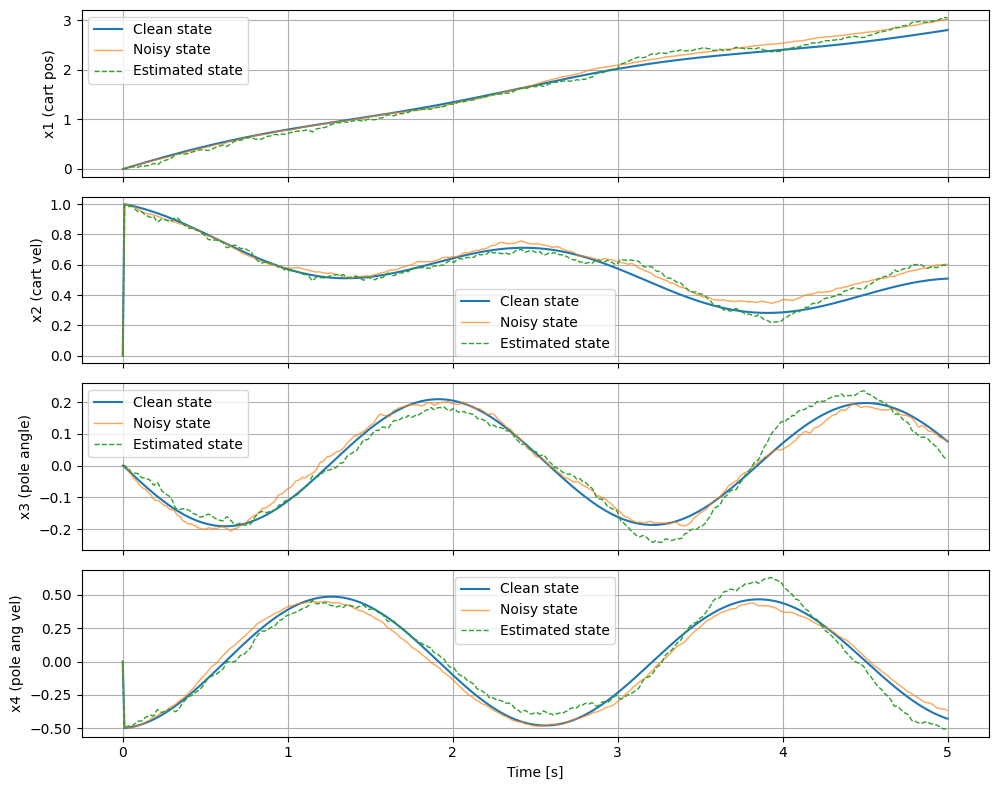

In [30]:
# 비교 플롯, x_clean, x_noisy, x_hat
fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
state_labels = [
    "x1 (cart pos)",
    "x2 (cart vel)",
    "x3 (pole angle)",
    "x4 (pole ang vel)",
]
for i in range(4):
    axs[i].plot(t, x_clean[:, i], label="Clean state", linewidth=1.5)
    axs[i].plot(t, x_noisy[:, i], label="Noisy state", linewidth=1.0, alpha=0.7)
    axs[i].plot(t, x_hat[:, i], label="Estimated state", linewidth=1.0, linestyle="--")
    axs[i].set_ylabel(state_labels[i])
    axs[i].legend()
    axs[i].grid(True)
axs[-1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()